### Import necessary libraries

In [1]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
import pickle
import spacy
import os
import re

### Download and transform data

In [2]:
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print(path)

/home/mz/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1


In [3]:
data = pd.read_csv(os.path.join(path, "spam.csv"), encoding="ISO-8859-1")

data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
data.shape

(5572, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
data["v1"].unique()

array(['ham', 'spam'], dtype=object)

#### Drop unecessary features

In [7]:
data.drop(data[["Unnamed: 2","Unnamed: 3","Unnamed: 4"]], axis=1, inplace=True)
data.rename(columns = {"v1":"Spam", "v2":"Text"}, inplace = True)

data.head()

,Spam,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Convert spam feature to int

In [8]:
data["Spam"] = data["Spam"].apply(lambda x: 1 if x=="spam" else 0)

data.head()

,Spam,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


#### Define and test preprocessing function

In [9]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess(text):
    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # lemmatization
    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_space
        and len(token) > 2
    ]

    return " ".join(tokens)

In [10]:
text = "The cats are running quickly in the beautiful gardens."

print(preprocess(text))

cat run quickly beautiful garden


#### Preprocess text data

In [11]:
data["Text"] = data["Text"].apply(lambda x: preprocess(x))

data.head()

,Spam,Text
0,0,jurong point crazy available bugis great world...
1,0,lar joking wif oni
2,1,free entry wkly comp win cup final tkts text r...
3,0,dun early hor
4,0,nah think go usf live


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Spam    5572 non-null   int64 
 1   Text    5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


### Plot classes

Text(0, 0.5, 'Number of Data points')

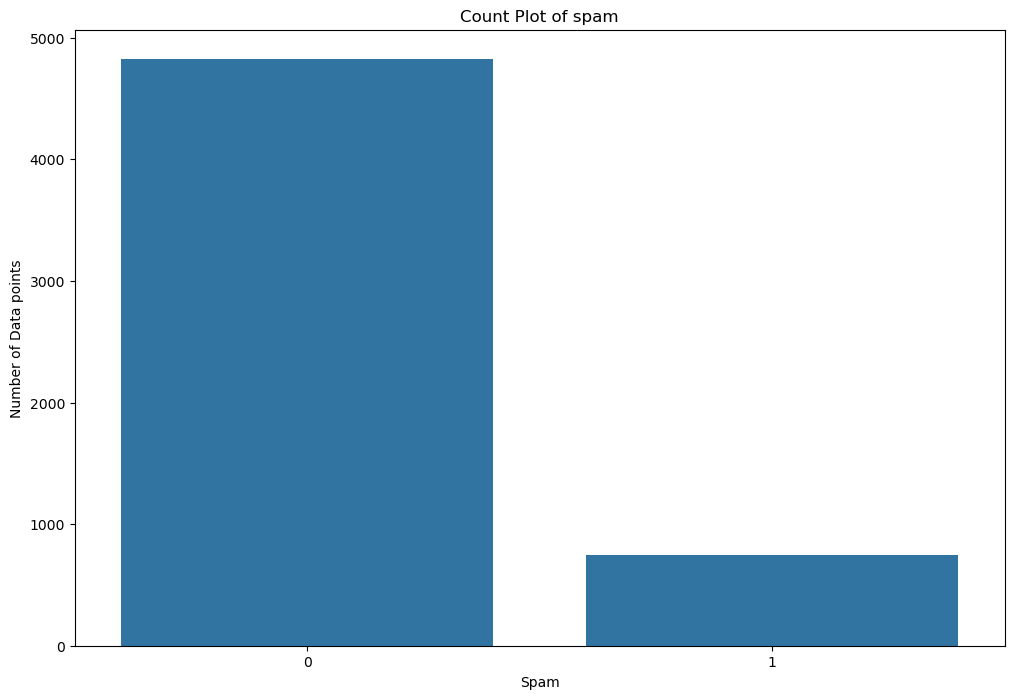

In [13]:
plt.figure(figsize=(12,8))
fig = sns.countplot(x=data["Spam"])
fig.set_title("Count Plot of spam")
fig.set_xlabel("Spam")
fig.set_ylabel("Number of Data points")

### Train model

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    data["Text"],
    data["Spam"],
    test_size=0.2,
    random_state=8,
    stratify=data["Spam"]
)

In [15]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000, random_state=8))
])

In [16]:
param_dist = {
    "tfidf__max_features": [None, 3000, 4000, 5000, 6000, 7000, 8000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3), (1, 4)],
    "tfidf__min_df": [1, 2, 3, 4, 5],
    "tfidf__max_df": [0.6, 0.7, 0.8, 0.9, 1.0],
    "clf__C": [0.01, 0.1, 1, 10, 100, 1000, 10000],
    "clf__solver": ["liblinear", "lbfgs"]
}

In [17]:
search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=20,
    cv=5,
    random_state=8,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

print("\nBest CV accuracy:")
print(search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 2, 'tfidf__max_features': None, 'tfidf__max_df': 0.9, 'clf__solver': 'liblinear', 'clf__C': 100}

Best CV accuracy:
0.9800315058909976


#### Evaluate model

Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.98      0.83      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



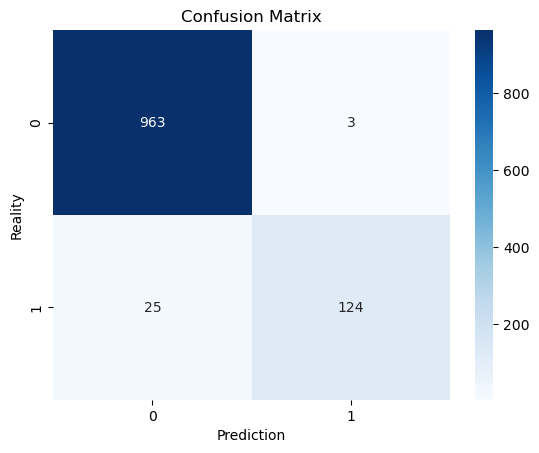

In [18]:
clf = search.best_estimator_

predictions = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.title("Confusion Matrix")
plt.show()

#### Test model on single samples

In [19]:
ham_text = "Hey, I'm running about 15 minutes late. I'll meet you at the café around 6:30 PM."
spam_text = "Congratulations! You've been selected to receive a FREE $500 shopping voucher. Click here to claim now: <link>"

ham_test = clf.predict([preprocess(ham_text)])[0]
print(f"Ham test: {ham_test}")

spam_test = clf.predict([preprocess(spam_text)])[0]
print(f"Spam test: {spam_test}")

texts = [
    "Don't forget to bring your laptop charger tomorrow. Mine stopped working and I may need yours.",                  # ham
    "URGENT: Your bank account has been temporarily suspended. Verify your identity immediately at <link>",            # spam
    "Thanks for helping me move yesterday! Let me know when you're free so I can buy you dinner.",                     # ham
    "WIN BIG TODAY! You've won a brand new iPhone 18. Reply 'YES' within 10 minutes to receive your prize.",           # spam
    "The meeting has been moved to Friday morning. I'll send the updated agenda later today.",                         # ham
    "Final notice! Your package is waiting for delivery. Pay the small customs fee now to avoid cancellation: <link>"  # spam
]

preprocessed = [preprocess(text) for text in texts]

results = clf.predict(preprocessed)
print(results)

Ham test: 0
Spam test: 1
[0 1 0 1 0 1]


#### Save model

In [20]:
with open("classifier_model.pkl", "wb") as file:
    pickle.dump(clf, file)